<a href="https://colab.research.google.com/github/hjfuytuyig/Hacktoberfest2021-Task2/blob/master/Indian_Airlines_Delay_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

airlines = ['IndiGo', 'Air India', 'SpiceJet', 'Vistara', 'Akasa Air']
airports = ['DEL', 'BOM', 'BLR', 'HYD', 'MAA', 'CCU']

n = 5000

df = pd.DataFrame({
    'airline': np.random.choice(airlines, n),
    'origin_airport': np.random.choice(airports, n),
    'destination_airport': np.random.choice(airports, n),
    'departure_delay': np.random.randint(-10, 120, n),
    'distance_km': np.random.randint(200, 2500, n),
    'weather': np.random.choice(['Clear', 'Rain', 'Fog'], n),
    'day_of_week': np.random.randint(1, 8, n),
    'departure_hour': np.random.randint(0, 24, n)
})

# Add realistic delay logic
df['arrival_delay'] = (
    df['departure_delay'] * 0.7 +
    np.where(df['weather'] == 'Rain', 20, 0) +
    np.where(df['weather'] == 'Fog', 30, 0) +
    np.random.normal(5, 10, n)
)

df.to_csv("indian_flights.csv", index=False)
df.head()

,airline,origin_airport,destination_airport,departure_delay,distance_km,weather,day_of_week,departure_hour,arrival_delay
0,Vistara,CCU,MAA,16,332,Clear,4,7,15.193803
1,Akasa Air,CCU,CCU,60,648,Fog,3,10,74.647643
2,SpiceJet,BOM,BOM,107,2030,Fog,1,16,104.833788
3,Akasa Air,MAA,DEL,-2,2358,Clear,6,13,-11.415036
4,Akasa Air,HYD,BLR,75,1049,Fog,7,18,96.837389


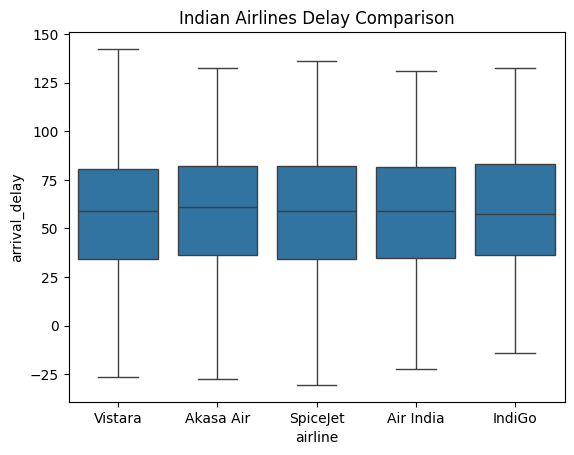

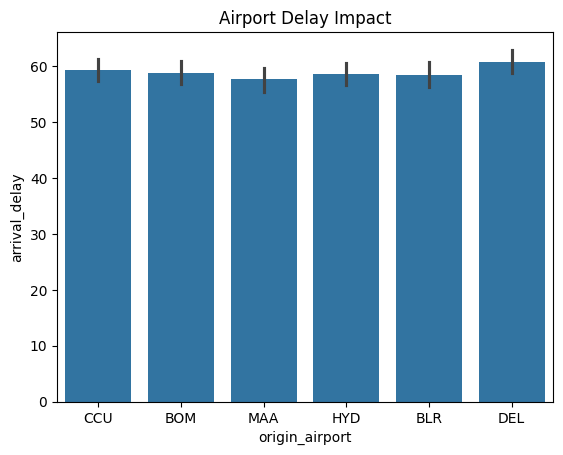

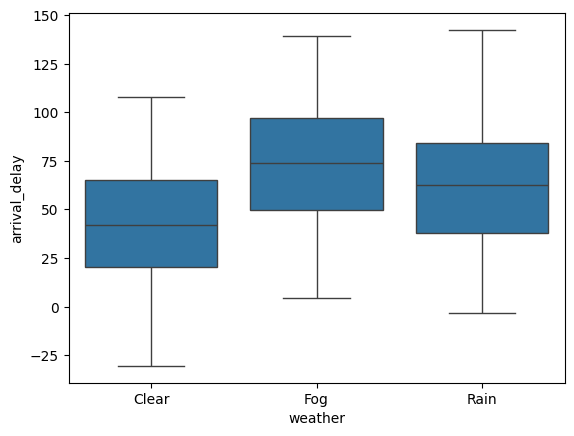

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Airline vs Delay
sns.boxplot(x='airline', y='arrival_delay', data=df)
plt.title("Indian Airlines Delay Comparison")
plt.show()

# Airport congestion
sns.barplot(x='origin_airport', y='arrival_delay', data=df)
plt.title("Airport Delay Impact")
plt.show()

# Weather effect
sns.boxplot(x='weather', y='arrival_delay', data=df)
plt.show()

In [4]:
df['arrival_delay'].fillna(df['arrival_delay'].mean(), inplace=True)
df = df[df['arrival_delay'] < 300]

/tmp/ipykernel_8913/2826991150.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['arrival_delay'].fillna(df['arrival_delay'].mean(), inplace=True)


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['airline', 'origin_airport', 'destination_airport', 'weather']:
    df[col] = le.fit_transform(df[col])

# Peak hours feature (important for India)
df['is_peak_hour'] = df['departure_hour'].apply(lambda x: 1 if 7 <= x <= 10 or 18 <= x <= 22 else 0)

# Delay classification
df['delay_status'] = df['arrival_delay'].apply(lambda x: 1 if x > 15 else 0)

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(['arrival_delay', 'delay_status'], axis=1)
y = df['delay_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, y_pred))

RF Accuracy: 0.957


In [8]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.953


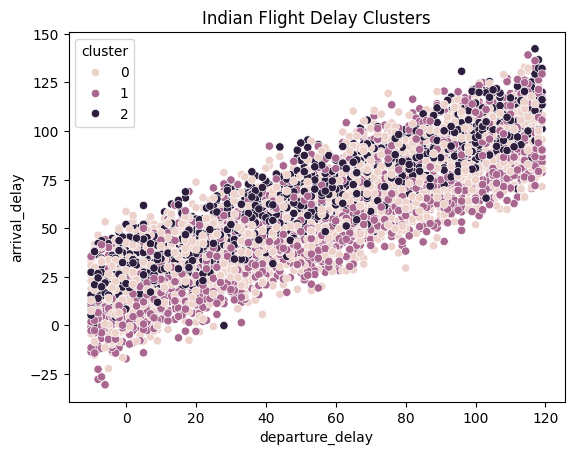

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(x='departure_delay', y='arrival_delay', hue='cluster', data=df)
plt.title("Indian Flight Delay Clusters")
plt.show()